In [17]:
# %pip install numpy
# %pip install pandas
# %pip install matplotlib
# %pip install seaborn
# %pip install scikit-learn
# %pip install tensorflow
# %pip install kaggle

In [18]:
import numpy as np
import pandas as pd
from pathlib import Path
import os.path

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
import tensorflow as tf
from sklearn.metrics import confusion_matrix, classification_report

## Data preparation

In [19]:
image_dir = Path("ingredients_dataset")

filepaths = list(image_dir.glob(r'**/*.jpg'))
labels = list(map(lambda x: os.path.split(os.path.split(x)[0])[1], filepaths))

# Put the image filepath and labels in a dataframe
filepaths = pd.Series(filepaths, name='Filepath').astype(str)
labels = pd.Series(labels, name='Label')
images = pd.concat([filepaths, labels], axis=1)

# Use a smaller sample size, for lower training time (also lower accuracy though)
category_samples = []
for category in images['Label'].unique():
    category_slice = images.query("Label == @category")
    sample_size = min(81, len(category_slice))
    category_samples.append(category_slice.sample(sample_size, random_state=1))
image_df = pd.concat(category_samples, axis=0).sample(frac=1.0, random_state=1).reset_index(drop=True)

In [20]:
# Train test split of 70% training size and 30% testing size
train_df, test_df = train_test_split(image_df, train_size=0.75, shuffle=True, random_state=1)

## Image data loader

In [21]:
# Training data generator with 20% validation split 
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2
)

# Test data generator
test_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [22]:
# Create data flows for training, validation, and testing
train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='training'
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=True,
    seed=42,
    subset='validation'
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col='Filepath',
    y_col='Label',
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=32,
    shuffle=False
)


Found 3010 validated image filenames belonging to 81 classes.
Found 752 validated image filenames belonging to 81 classes.
Found 1255 validated image filenames belonging to 81 classes.


## Model architecture

In [ ]:
# Load pre-trained MobileNetV2
pretrained_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='avg'
)

pretrained_model.trainable = False

In [24]:
# Add 3 new custom layers
inputs = pretrained_model.input

x = tf.keras.layers.Dense(128, activation='relu')(pretrained_model.output)
x = tf.keras.layers.Dense(128, activation='relu')(x)

outputs = tf.keras.layers.Dense(81, activation='softmax')(x)

# Combine into a final model
model = tf.keras.Model(inputs, outputs)

In [25]:
# Compile model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train model
history = model.fit(
    train_images,
    validation_data=val_images,
    epochs=100,
    callbacks=[
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=3,
            restore_best_weights=True
        )
    ]
)

Epoch 1/100


C:\Users\brech\AppData\Roaming\Python\Python312\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


95/95 ━━━━━━━━━━━━━━━━━━━━ 22s 206ms/step - accuracy: 0.2104 - loss: 3.5349 - val_accuracy: 0.6024 - val_loss: 1.4204
Epoch 2/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 191ms/step - accuracy: 0.7620 - loss: 0.9406 - val_accuracy: 0.7367 - val_loss: 0.8543
Epoch 3/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 186ms/step - accuracy: 0.9118 - loss: 0.3761 - val_accuracy: 0.8032 - val_loss: 0.6441
Epoch 4/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.9403 - loss: 0.2281 - val_accuracy: 0.8245 - val_loss: 0.5311
Epoch 5/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 19s 195ms/step - accuracy: 0.9772 - loss: 0.1232 - val_accuracy: 0.8697 - val_loss: 0.4610
Epoch 6/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 20s 207ms/step - accuracy: 0.9907 - loss: 0.0677 - val_accuracy: 0.8590 - val_loss: 0.4587
Epoch 7/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 189ms/step - accuracy: 0.9945 - loss: 0.0504 - val_accuracy: 0.8830 - val_loss: 0.3772
Epoch 8/100
95/95 ━━━━━━━━━━━━━━━━━━━━ 18s 193ms/step - accuracy: 1.0000 - loss: 0.0235 - val_accuracy

## Evaluation

In [26]:
# Calculate test accuracy
results = model.evaluate(test_images, verbose=0)
print("Test Accuracy: {:.2f}%".format(results[1] * 100))

Test Accuracy: 89.48%


In [27]:
# Generate predictions
predictions = np.argmax(model.predict(test_images), axis=1)

# Calculate confusion matrix and classification report
cm = confusion_matrix(test_images.labels, predictions)
clr = classification_report(test_images.labels, predictions, target_names=test_images.class_indices, zero_division=0)

40/40 ━━━━━━━━━━━━━━━━━━━━ 8s 175ms/step


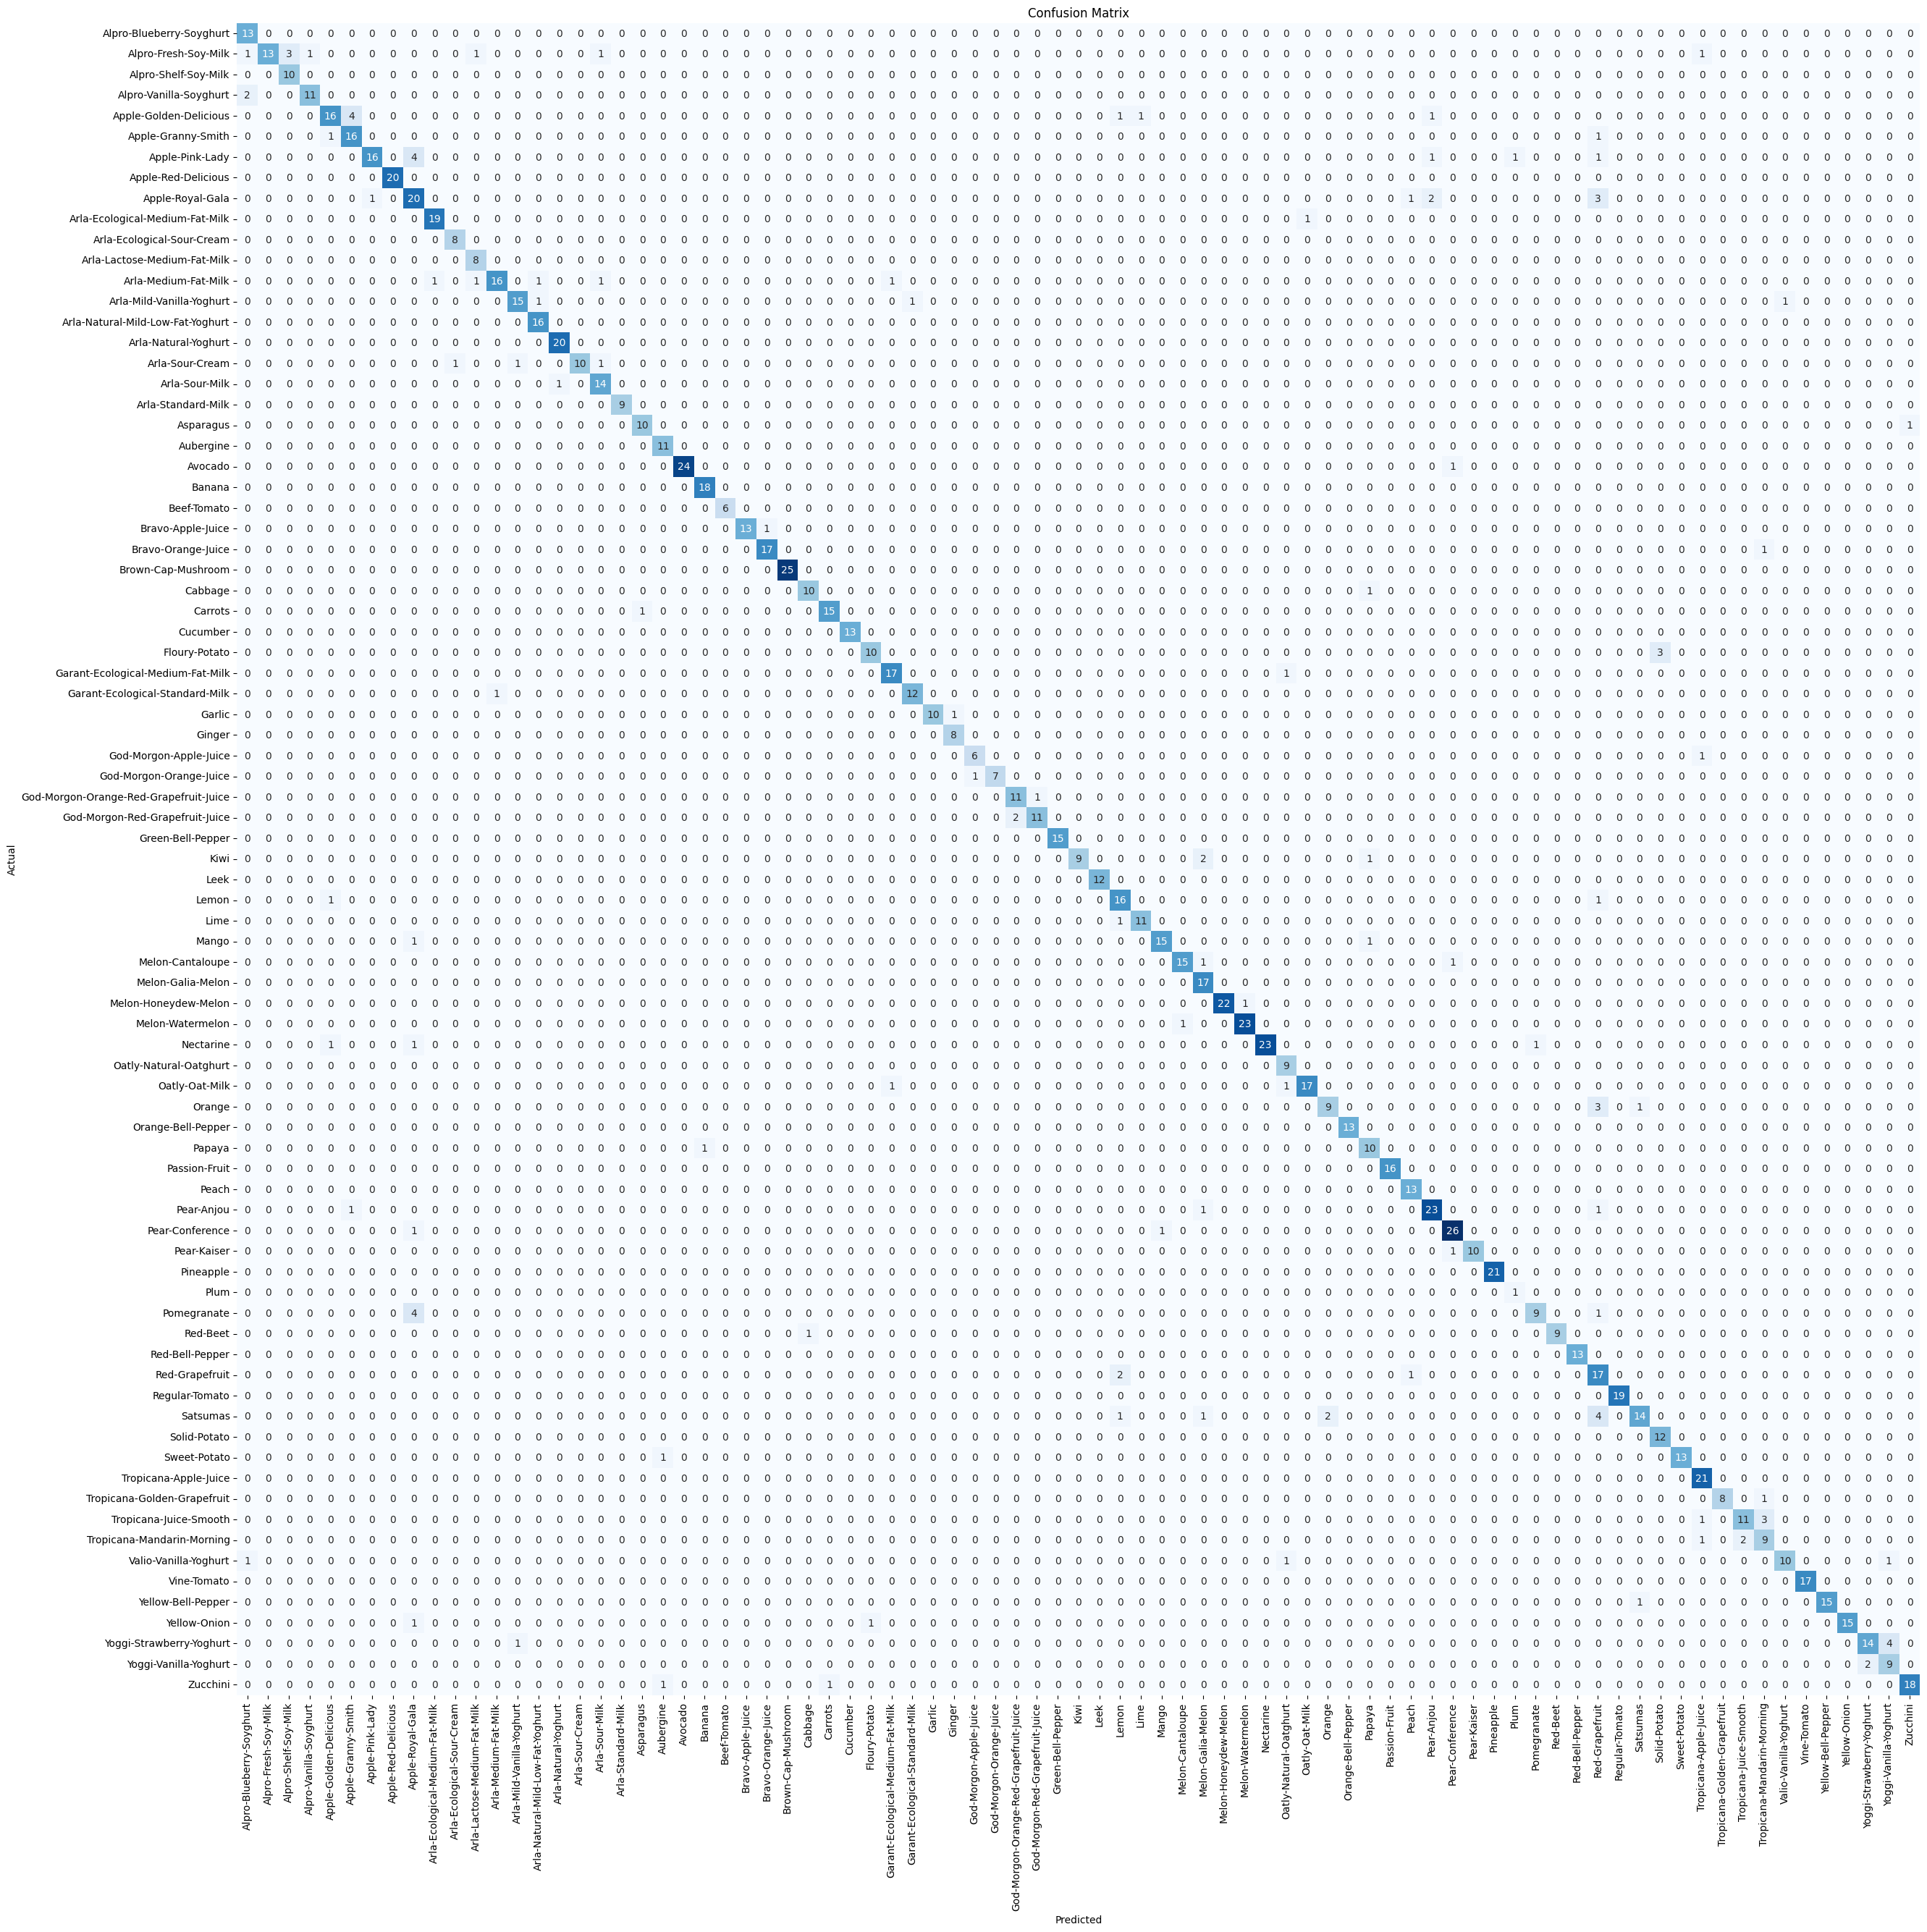

In [28]:
# Show Confusion matrix
plt.figure(figsize=(30, 30))
sns.heatmap(cm, annot=True, fmt='g', vmin=0, cmap='Blues', cbar=False)
plt.xticks(ticks=np.arange(81) + 0.5, labels=test_images.class_indices, rotation=90)
plt.yticks(ticks=np.arange(81) + 0.5, labels=test_images.class_indices, rotation=0)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# Show classification report
print("Classification Report:\n----------------------\n", clr)

Classification Report:
----------------------
                                         precision    recall  f1-score   support

              Alpro-Blueberry-Soyghurt       0.76      1.00      0.87        13
                  Alpro-Fresh-Soy-Milk       1.00      0.62      0.76        21
                  Alpro-Shelf-Soy-Milk       0.77      1.00      0.87        10
                Alpro-Vanilla-Soyghurt       0.92      0.85      0.88        13
                Apple-Golden-Delicious       0.84      0.70      0.76        23
                    Apple-Granny-Smith       0.76      0.89      0.82        18
                       Apple-Pink-Lady       0.94      0.70      0.80        23
                   Apple-Red-Delicious       1.00      1.00      1.00        20
                      Apple-Royal-Gala       0.62      0.74      0.68        27
       Arla-Ecological-Medium-Fat-Milk       0.95      0.95      0.95        20
            Arla-Ecological-Sour-Cream       0.89      1.00      0.94   

In [30]:
# Save trained model
model.save('ingredients_classification_model.h5')

In [31]:
import pickle
# Save class labels
class_labels = list(train_images.class_indices.keys())
with open('class_labels.pkl', 'wb') as f:
    pickle.dump(class_labels, f)

In [32]:
class_labels

['Alpro-Blueberry-Soyghurt',
 'Alpro-Fresh-Soy-Milk',
 'Alpro-Shelf-Soy-Milk',
 'Alpro-Vanilla-Soyghurt',
 'Apple-Golden-Delicious',
 'Apple-Granny-Smith',
 'Apple-Pink-Lady',
 'Apple-Red-Delicious',
 'Apple-Royal-Gala',
 'Arla-Ecological-Medium-Fat-Milk',
 'Arla-Ecological-Sour-Cream',
 'Arla-Lactose-Medium-Fat-Milk',
 'Arla-Medium-Fat-Milk',
 'Arla-Mild-Vanilla-Yoghurt',
 'Arla-Natural-Mild-Low-Fat-Yoghurt',
 'Arla-Natural-Yoghurt',
 'Arla-Sour-Cream',
 'Arla-Sour-Milk',
 'Arla-Standard-Milk',
 'Asparagus',
 'Aubergine',
 'Avocado',
 'Banana',
 'Beef-Tomato',
 'Bravo-Apple-Juice',
 'Bravo-Orange-Juice',
 'Brown-Cap-Mushroom',
 'Cabbage',
 'Carrots',
 'Cucumber',
 'Floury-Potato',
 'Garant-Ecological-Medium-Fat-Milk',
 'Garant-Ecological-Standard-Milk',
 'Garlic',
 'Ginger',
 'God-Morgon-Apple-Juice',
 'God-Morgon-Orange-Juice',
 'God-Morgon-Orange-Red-Grapefruit-Juice',
 'God-Morgon-Red-Grapefruit-Juice',
 'Green-Bell-Pepper',
 'Kiwi',
 'Leek',
 'Lemon',
 'Lime',
 'Mango',
 'Melon-Ca